#  Prédiction de Prix Immobilier — Conforme RGPD avec Détection de Biais

**Objectif** : Construire un modèle de prédiction de prix immobilier en respectant les bonnes pratiques RGPD et en analysant les biais potentiels.

**Pipeline :**
1. Chargement des données
2. Nettoyage et préparation (Livrable 1)
3. Feature Engineering (Livrable 2)
4. Modélisation et évaluation (Livrable 3)
5. Analyse des biais (Livrable 4)

---

# **0. Installation et Imports**

In [ ]:
# ── Librairies standard ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

# ── Style global ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

print('Imports OK')

Imports OK


## 1. Chargement des données

In [ ]:
train = pd.read_csv('train.csv')
test  = pd.read_csv('test.csv')

print(f'Train : {train.shape[0]} lignes × {train.shape[1]} colonnes')
print(f'Test  : {test.shape[0]}  lignes × {test.shape[1]} colonnes')
train.head(3)

Train : 1460 lignes × 81 colonnes
Test  : 1459  lignes × 80 colonnes


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


=== Distribution de SalePrice ===
count      1,460
mean     180,921
std       79,443
min       34,900
25%      129,975
50%      163,000
75%      214,000
max      755,000
Name: SalePrice, dtype: object


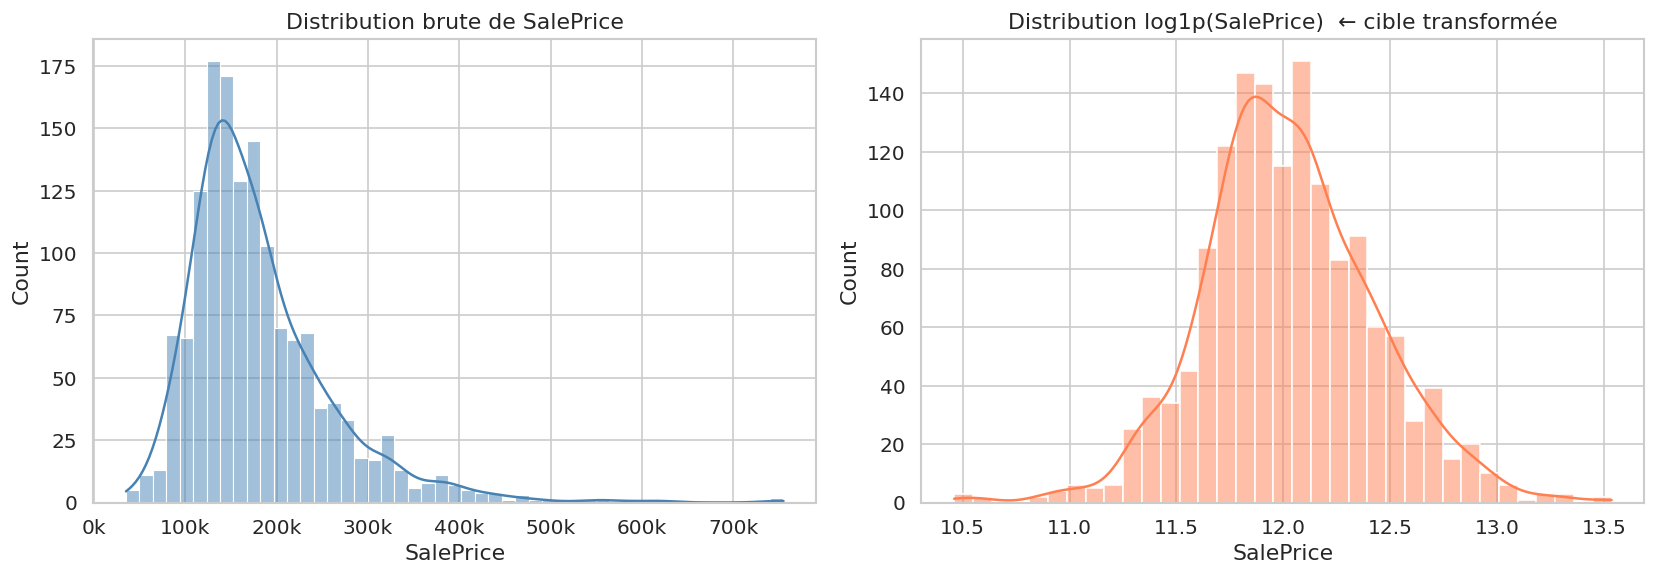

In [ ]:
# Statistiques descriptives de la cible
print('=== Distribution de SalePrice ===')
print(train['SalePrice'].describe().apply(lambda x: f'{x:,.0f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(train['SalePrice'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribution brute de SalePrice')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

sns.histplot(np.log1p(train['SalePrice']), kde=True, ax=axes[1], color='coral')
axes[1].set_title('Distribution log1p(SalePrice)  ← cible transformée')
plt.tight_layout()
plt.show()

---
# **1 Nettoyage et Préparation**

### 1.1 Analyse des valeurs manquantes (Heatmap)

Colonnes avec valeurs manquantes : 19 / 81


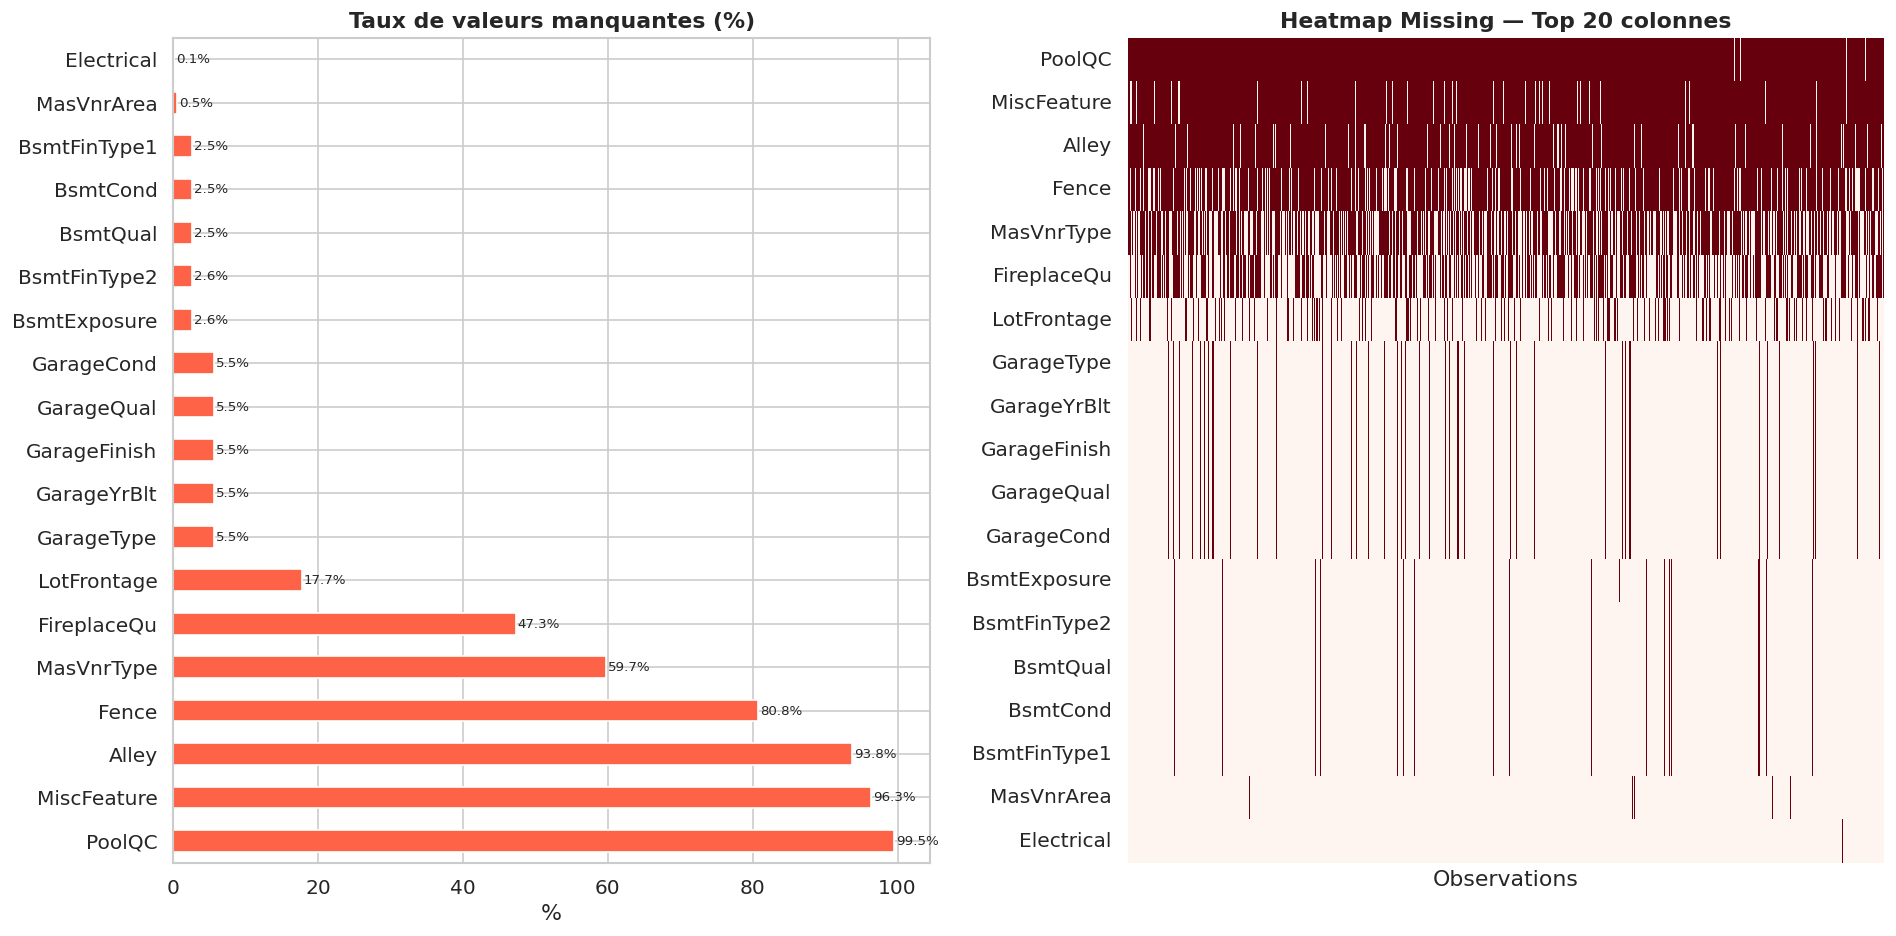

In [ ]:
# Taux de valeurs manquantes par colonne (seulement les colonnes concernées)
missing = train.isnull().mean() * 100
missing = missing[missing > 0].sort_values(ascending=False)

print(f'Colonnes avec valeurs manquantes : {len(missing)} / {train.shape[1]}')

# ── Heatmap globale ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Barplot du taux de missing
missing.plot(kind='barh', ax=axes[0], color='tomato', edgecolor='white')
axes[0].set_title('Taux de valeurs manquantes (%)', fontweight='bold')
axes[0].set_xlabel('%')
for bar in axes[0].patches:
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{bar.get_width():.1f}%', va='center', fontsize=8)

# Heatmap sur un sous-ensemble
top_missing_cols = missing.index[:20].tolist()
sample = train[top_missing_cols].isnull().astype(int)
sns.heatmap(sample.T, cmap='Reds', cbar=False, ax=axes[1],
            xticklabels=False, yticklabels=True, linewidths=0)
axes[1].set_title('Heatmap Missing — Top 20 colonnes', fontweight='bold')
axes[1].set_xlabel('Observations')

plt.tight_layout()
plt.show()

### 1.2 Stratégie d'imputation justifiée

| Catégorie | Colonnes | Stratégie | Justification |
|-----------|----------|-----------|---------------|
| Absence réelle | PoolQC, Fence, MiscFeature, Alley, FireplaceQu | Remplir par `'None'` | NA signifie « pas de piscine / garage / etc. » |
| Garage | GarageType, GarageFinish, GarageQual, GarageCond | `'None'` / 0 | Maison sans garage |
| Sous-sol | BsmtQual, BsmtCond, BsmtExposure, BsmtFinType1/2 | `'None'` / 0 | Maison sans sous-sol |
| Numérique faible | LotFrontage | Médiane par quartier | Corrélation spatiale |
| Numérique rare | MasVnrArea | 0 | Valeur logique |
| Catégoriel rare | Electrical, MasVnrType | Mode | Peu de NA, remplacement neutre |

In [ ]:
def impute_missing(df: pd.DataFrame) -> pd.DataFrame:
    """Imputation conforme à la stratégie documentée ci-dessus."""
    df = df.copy()

    # ── Catégoriels → 'None' (absence réelle) ──────────────────────────────
    none_cols = [
        'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
        'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'MasVnrType'
    ]
    for col in none_cols:
        if col in df.columns:
            df[col] = df[col].fillna('None')

    # ── Numériques → 0 (absence réelle) ───────────────────────────────────
    zero_cols = [
        'GarageYrBlt', 'GarageArea', 'GarageCars',
        'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        'BsmtFullBath', 'BsmtHalfBath', 'MasVnrArea'
    ]
    for col in zero_cols:
        if col in df.columns:
            df[col] = df[col].fillna(0)

    # ── LotFrontage → médiane par Neighborhood ─────────────────────────────
    df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(
        lambda x: x.fillna(x.median())
    )

    # ── Electrical → mode ─────────────────────────────────────────────────
    if 'Electrical' in df.columns:
        df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

    # ── Résiduel → mode pour catégoriels, médiane pour numériques ─────────
    for col in df.columns:
        if df[col].isnull().any():
            if df[col].dtype == 'object':
                df[col] = df[col].fillna(df[col].mode()[0])
            else:
                df[col] = df[col].fillna(df[col].median())

    return df

train = impute_missing(train)
test  = impute_missing(test)

missing_after = train.isnull().sum().sum()
print(f'✅ Valeurs manquantes restantes : {missing_after}')

✅ Valeurs manquantes restantes : 0


### 1.3 Détection et traitement des outliers

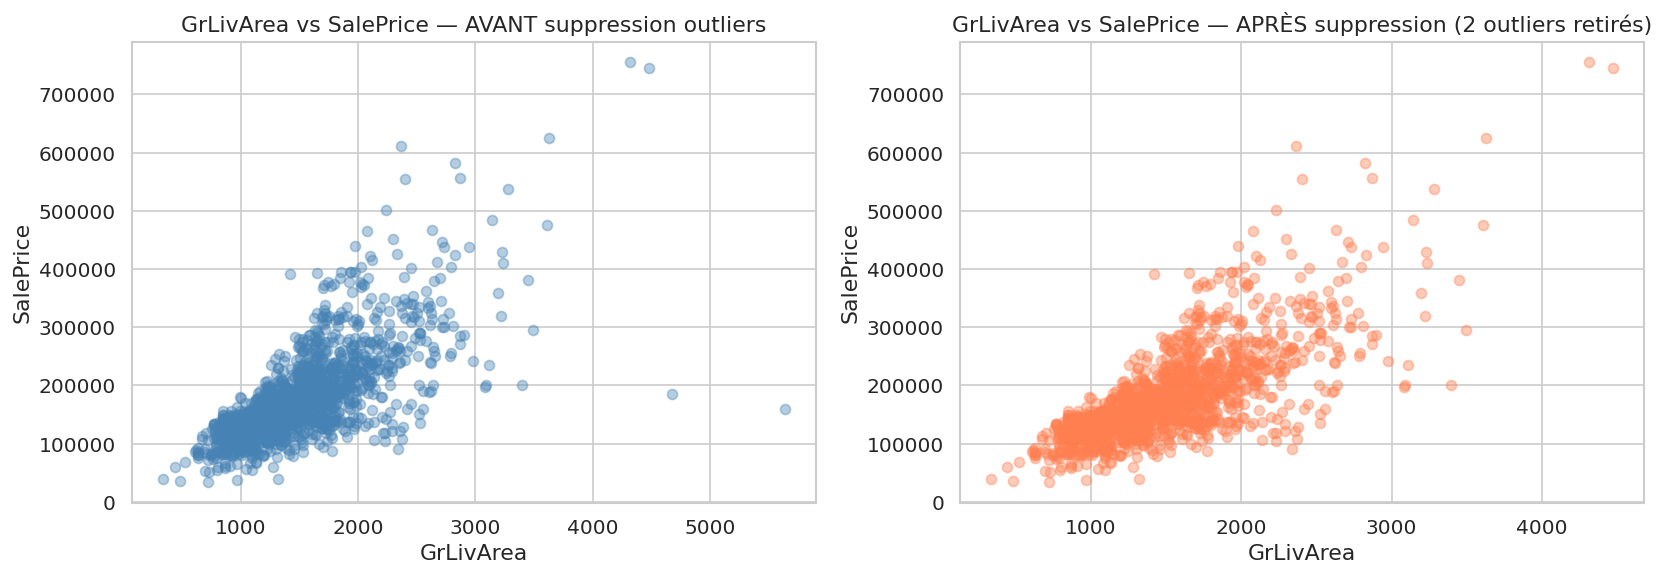

Lignes restantes : 1458


In [ ]:
# Visualisation avant suppression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='steelblue')
axes[0].set_xlabel('GrLivArea'); axes[0].set_ylabel('SalePrice')
axes[0].set_title('GrLivArea vs SalePrice — AVANT suppression outliers')

# Suppression des outliers documentés (grandes surfaces + prix bas → ventes atypiques)
outlier_mask = ~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300_000))
n_removed = (~outlier_mask).sum()
train = train[outlier_mask].reset_index(drop=True)

axes[1].scatter(train['GrLivArea'], train['SalePrice'], alpha=0.4, color='coral')
axes[1].set_xlabel('GrLivArea'); axes[1].set_ylabel('SalePrice')
axes[1].set_title(f'GrLivArea vs SalePrice — APRÈS suppression ({n_removed} outliers retirés)')
plt.tight_layout(); plt.show()
print(f'Lignes restantes : {len(train)}')

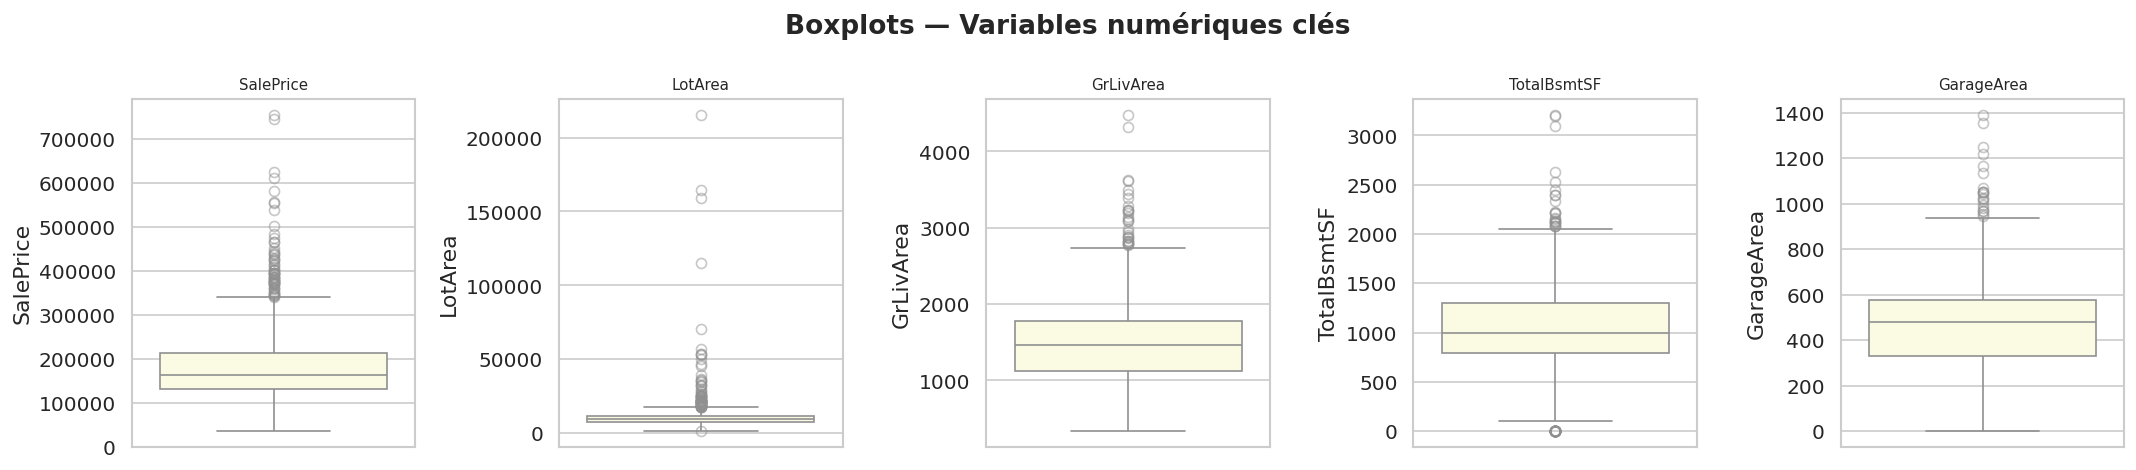

In [ ]:
# Outliers numériques via IQR — visualisation boxplot des variables clés
num_cols_check = ['SalePrice', 'LotArea', 'GrLivArea', 'TotalBsmtSF', 'GarageArea']

fig, axes = plt.subplots(1, len(num_cols_check), figsize=(18, 4))
for ax, col in zip(axes, num_cols_check):
    sns.boxplot(y=train[col], ax=ax, color='lightyellow', flierprops=dict(marker='o', color='tomato', alpha=0.5))
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots — Variables numériques clés', fontweight='bold')
plt.tight_layout(); plt.show()

### 1.4 Encodage des variables catégorielles

In [ ]:
# Séparation target
y = np.log1p(train['SalePrice'])          # log-transform pour normaliser la cible
train_ids = train['Id']
test_ids  = test['Id']

# Concaténation pour encodage cohérent train + test
all_data = pd.concat([train.drop(columns=['Id', 'SalePrice']),
                       test.drop(columns=['Id'])], axis=0).reset_index(drop=True)

cat_cols = all_data.select_dtypes(include='object').columns.tolist()
print(f'Variables catégorielles à encoder : {len(cat_cols)}')

# Label Encoding (ordinal logique) + One-Hot pour les non-ordinales à faible cardinalité
# Choix : LabelEncoder sur toutes — simple, efficace pour les modèles arborescents
le = LabelEncoder()
for col in cat_cols:
    all_data[col] = le.fit_transform(all_data[col].astype(str))

print(f'Shape après encodage : {all_data.shape}')
all_data.head(2)

Variables catégorielles à encoder : 43
Shape après encodage : (2917, 79)


,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,60,3,65.0,8450,1,1,3,3,0,4,...,0,0,3,4,1,0,2,2008,8,4
1,20,3,80.0,9600,1,1,3,3,0,2,...,0,0,3,4,1,0,5,2007,8,4


---
# **2 — Feature Engineering**

✅ Nouvelles variables créées :
       AgeLogement  SurfaceTotale  NbSallesDeBain
count      2917.00        2917.00         2917.00
mean         53.71        2547.22            1.76
std          30.29         782.03            0.64
min          15.00         334.00            0.00
25%          24.00        2004.00            1.00
50%          52.00        2452.00            2.00
75%          72.00        2995.00            2.50
max         153.00       10190.00            5.00


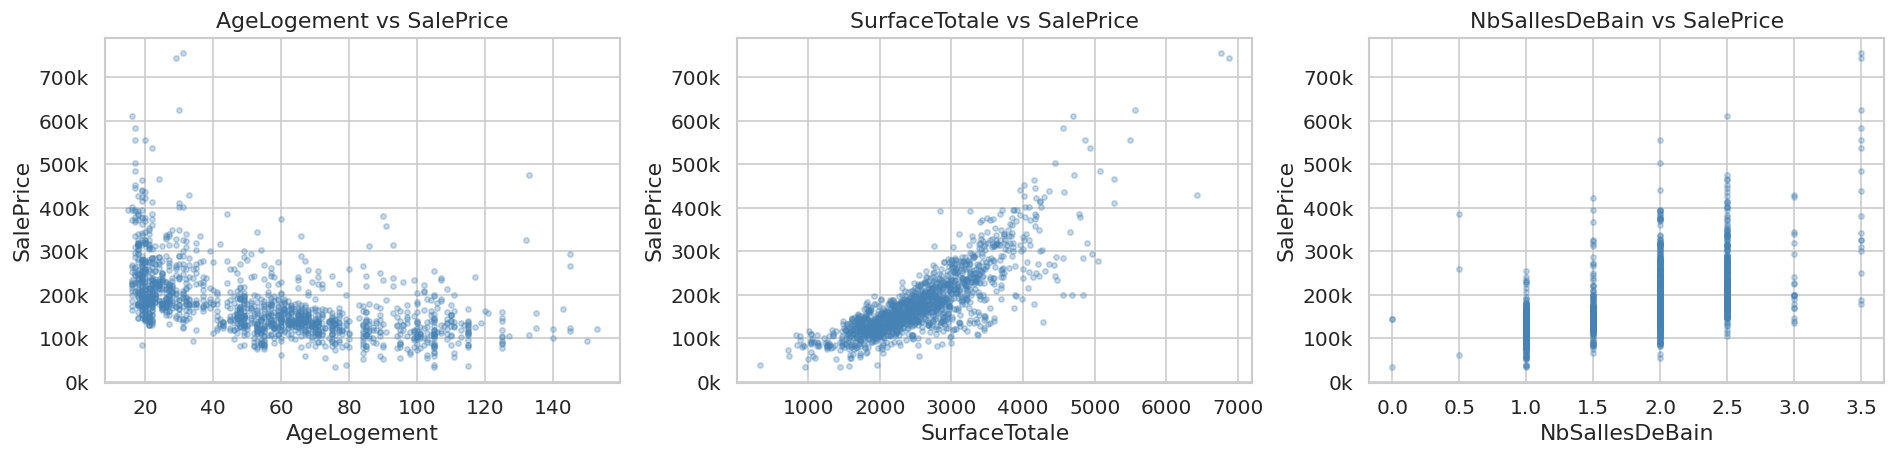

In [ ]:
# ── Création des nouvelles variables ──────────────────────────────────────────
all_data['AgeLogement']    = 2025 - train['YearBuilt'].reindex(all_data.index).fillna(
                                 all_data.get('YearBuilt', pd.Series(dtype=float)))

# Re-calcul depuis all_data directement (colonnes déjà encodées numériquement)
# On récupère les valeurs numériques brutes depuis train/test avant encodage
train_fe = train.drop(columns=['SalePrice']).copy()
test_fe  = test.copy()
all_raw  = pd.concat([train_fe, test_fe], axis=0).reset_index(drop=True)

all_raw['AgeLogement']   = 2025 - all_raw['YearBuilt']
all_raw['SurfaceTotale'] = all_raw['GrLivArea'] + all_raw['TotalBsmtSF']
all_raw['NbSallesDeBain']= all_raw['FullBath'] + 0.5 * all_raw['HalfBath']

# ── Suppression des colonnes redondantes ─────────────────────────────────────
cols_to_drop = ['YearBuilt', 'GrLivArea', 'TotalBsmtSF']
all_raw.drop(columns=[c for c in cols_to_drop if c in all_raw.columns], inplace=True)

print('✅ Nouvelles variables créées :')
print(all_raw[['AgeLogement', 'SurfaceTotale', 'NbSallesDeBain']].describe().round(2))

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
n_train = len(train)

for ax, feat in zip(axes, ['AgeLogement', 'SurfaceTotale', 'NbSallesDeBain']):
    vals = all_raw[feat].iloc[:n_train]
    ax.scatter(vals, np.expm1(y), alpha=0.3, s=10, color='steelblue')
    ax.set_xlabel(feat); ax.set_ylabel('SalePrice')
    ax.set_title(f'{feat} vs SalePrice')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))

plt.tight_layout(); plt.show()

In [ ]:
# Encodage final après feature engineering
cat_cols2 = all_raw.select_dtypes(include='object').columns.tolist()
for col in cat_cols2:
    all_raw[col] = LabelEncoder().fit_transform(all_raw[col].astype(str))

# Imputation résiduelle
for col in all_raw.columns:
    if all_raw[col].isnull().any():
        all_raw[col] = all_raw[col].fillna(all_raw[col].median())

# Reconstruction train/test
X       = all_raw.iloc[:n_train].drop(columns=['Id'])
X_test  = all_raw.iloc[n_train:].drop(columns=['Id'])

print(f'X train : {X.shape}  |  X test : {X_test.shape}')

X train : (1458, 79)  |  X test : (1459, 79)


---
# **3 — Modélisation et Évaluation**

In [ ]:
# ── Split train / validation ──────────────────────────────────────────────────
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train : {X_train.shape[0]} | Val : {X_val.shape[0]}')

Train : 1166 | Val : 292


In [ ]:
# ── Définition des modèles ────────────────────────────────────────────────────
models = {
    'Régression Linéaire': Pipeline([
        ('scaler', StandardScaler()),
        ('model',  LinearRegression())
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=300, max_depth=None,
        min_samples_split=5, random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, subsample=0.8, random_state=42
    )
}

# ── Entraînement et évaluation ────────────────────────────────────────────────
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_val)

    r2   = r2_score(y_val, preds)
    mae  = mean_absolute_error(np.expm1(y_val), np.expm1(preds))
    rmse = np.sqrt(mean_squared_error(y_val, preds))   # RMSLE

    # Cross-val 5 folds
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2', n_jobs=-1)

    results[name] = {
        'R²':    round(r2, 4),
        'MAE (€)': round(mae, 0),
        'RMSLE':  round(rmse, 4),
        'CV R² (mean)': round(cv_scores.mean(), 4),
        'CV R² (std)':  round(cv_scores.std(), 4),
    }
    print(f'✅ {name} — R²={r2:.4f} | MAE={mae:,.0f}€ | RMSLE={rmse:.4f}')

results_df = pd.DataFrame(results).T
print('\n── Tableau comparatif ──')
results_df

✅ Régression Linéaire — R²=0.9044 | MAE=14,681€ | RMSLE=0.1270
✅ Random Forest — R²=0.8802 | MAE=16,516€ | RMSLE=0.1421
✅ Gradient Boosting — R²=0.9105 | MAE=14,296€ | RMSLE=0.1228

── Tableau comparatif ──


,R²,MAE (€),RMSLE,CV R² (mean),CV R² (std)
Régression Linéaire,0.9044,14681.0,0.1270,0.9052,0.0034
Random Forest,0.8802,16516.0,0.1421,0.8835,0.0090
Gradient Boosting,0.9105,14296.0,0.1228,0.9110,0.0081


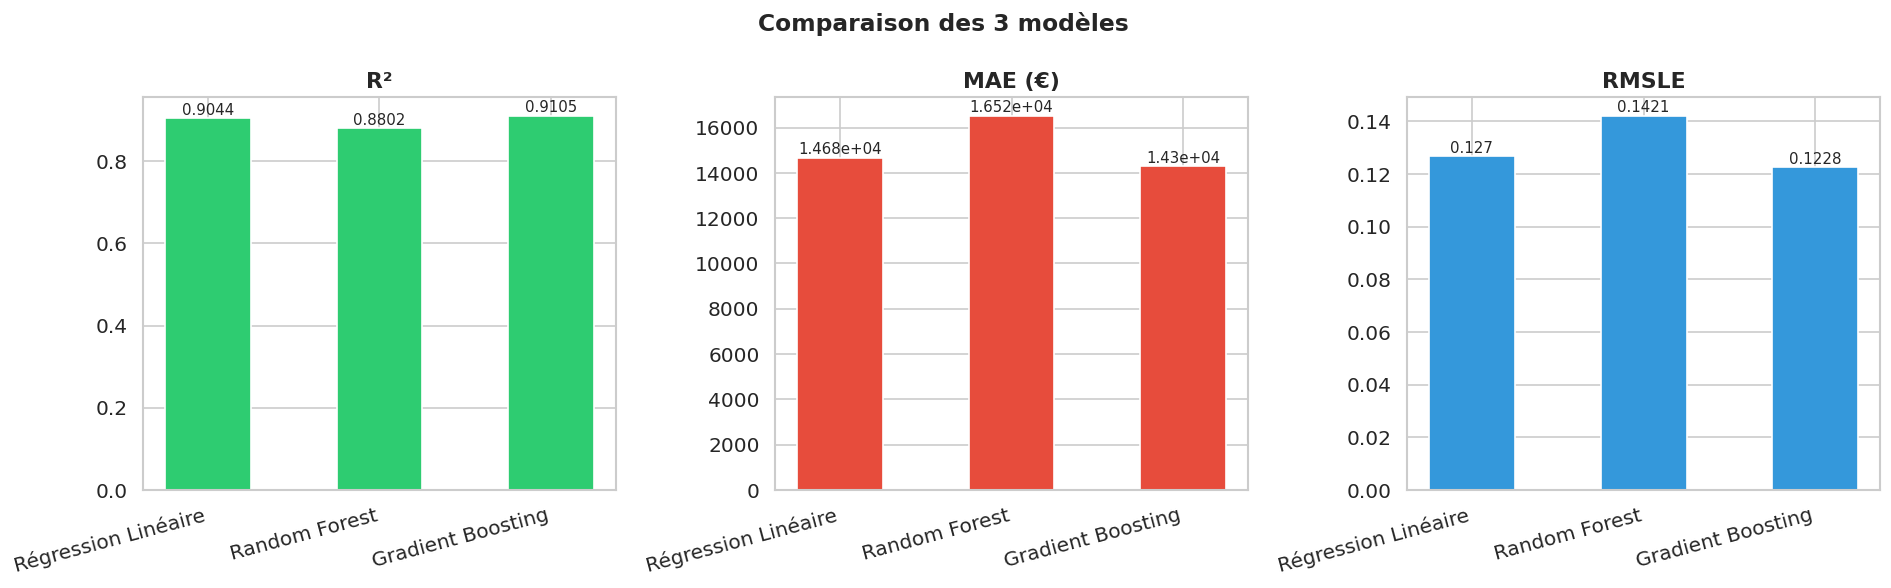

In [ ]:
# ── Visualisation des performances ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = ['R²', 'MAE (€)', 'RMSLE']
colors  = ['#2ecc71', '#e74c3c', '#3498db']

for ax, metric, color in zip(axes, metrics, colors):
    vals = results_df[metric].astype(float)
    bars = ax.bar(results_df.index, vals, color=color, edgecolor='white', width=0.5)
    ax.set_title(metric, fontweight='bold')
    ax.set_xticklabels(results_df.index, rotation=15, ha='right')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                f'{val:,.4g}', ha='center', fontsize=9)

plt.suptitle('Comparaison des 3 modèles', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

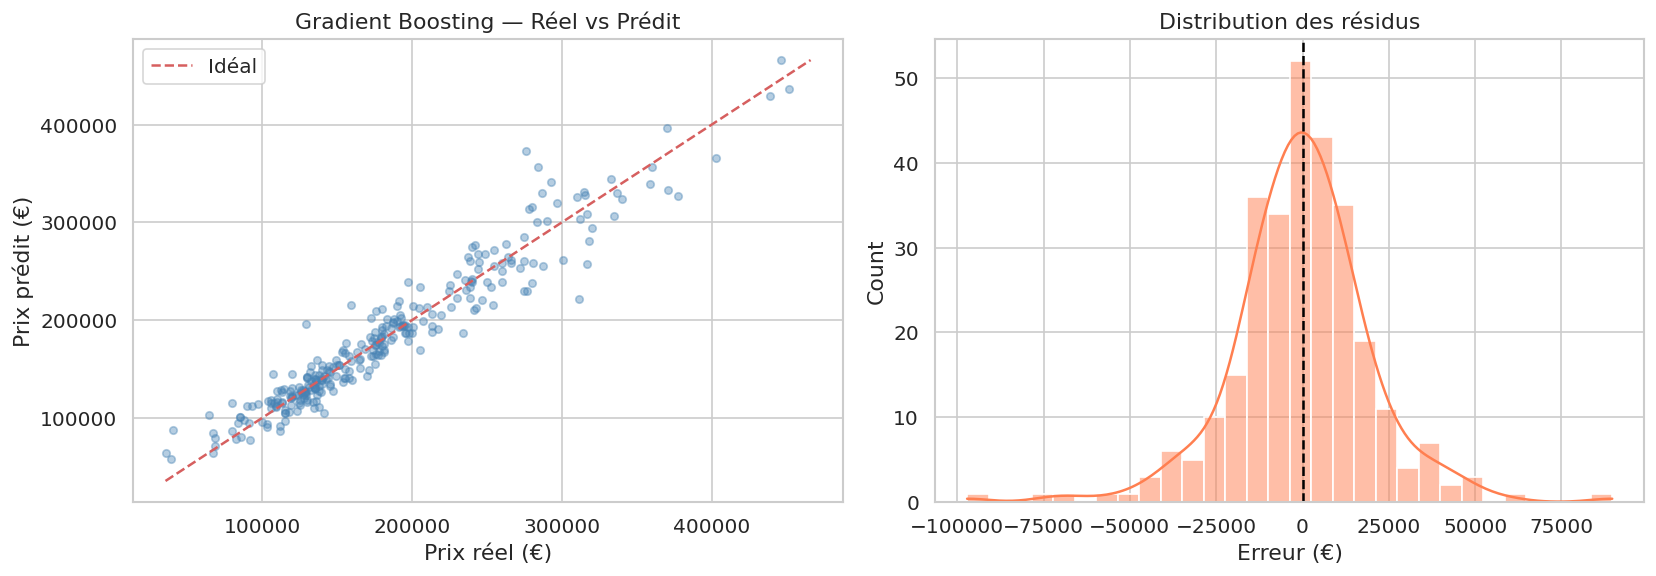

In [ ]:
# ── Prédictions réelles vs prédites — meilleur modèle ─────────────────────────
best_name = results_df['R²'].astype(float).idxmax()
best_model = models[best_name]
best_preds = best_model.predict(X_val)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(np.expm1(y_val), np.expm1(best_preds), alpha=0.4, s=20, color='steelblue')
lims = [min(np.expm1(y_val).min(), np.expm1(best_preds).min()),
        max(np.expm1(y_val).max(), np.expm1(best_preds).max())]
axes[0].plot(lims, lims, 'r--', lw=1.5, label='Idéal')
axes[0].set_xlabel('Prix réel (€)'); axes[0].set_ylabel('Prix prédit (€)')
axes[0].set_title(f'{best_name} — Réel vs Prédit')
axes[0].legend()

residuals = np.expm1(y_val) - np.expm1(best_preds)
sns.histplot(residuals, kde=True, ax=axes[1], color='coral')
axes[1].axvline(0, color='black', linestyle='--')
axes[1].set_title('Distribution des résidus')
axes[1].set_xlabel('Erreur (€)')

plt.tight_layout(); plt.show()

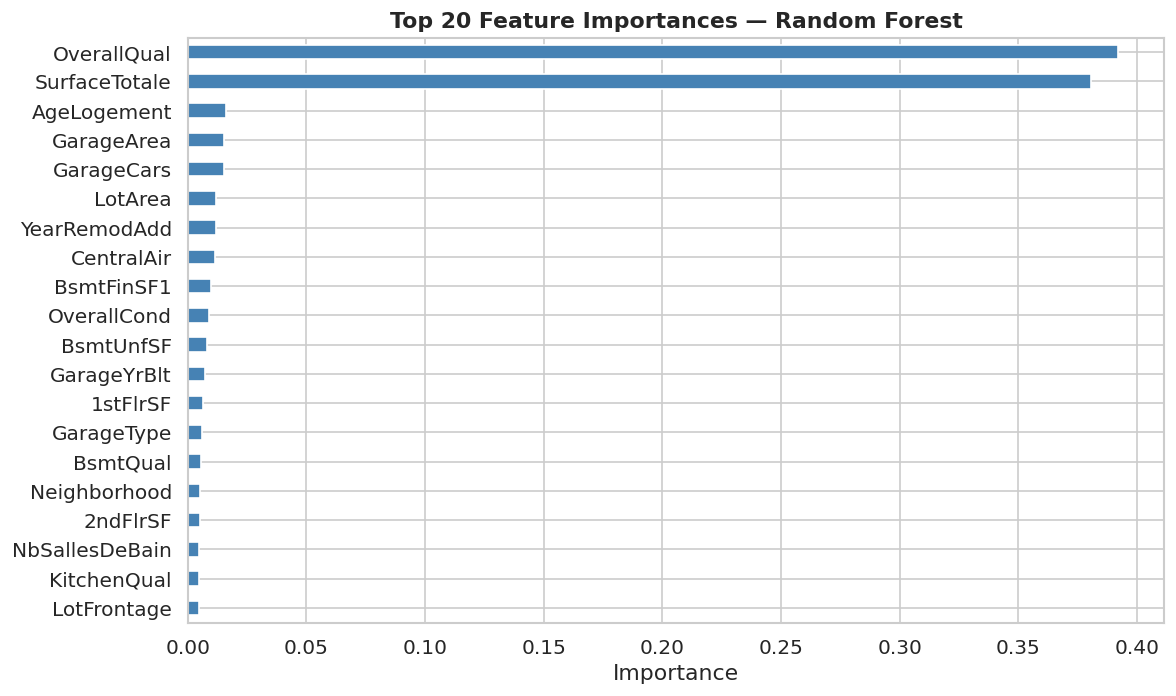

In [ ]:
# ── Feature Importance — Random Forest ───────────────────────────────────────
rf_model = models['Random Forest']
fi = pd.Series(rf_model.feature_importances_, index=X.columns)\
       .sort_values(ascending=False)[:20]

plt.figure(figsize=(10, 6))
fi.plot(kind='barh', color='steelblue', edgecolor='white')
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importances — Random Forest', fontweight='bold')
plt.xlabel('Importance')
plt.tight_layout(); plt.show()

In [ ]:
print(f'Le meilleur modèle est : {best_name}')
print(f"Ses performances sur l'ensemble de validation sont :")
print(results_df.loc[best_name])

Le meilleur modèle est : Gradient Boosting
Ses performances sur l'ensemble de validation sont :
R²                  0.9105
MAE (€)         14296.0000
RMSLE               0.1228
CV R² (mean)        0.9110
CV R² (std)         0.0081
Name: Gradient Boosting, dtype: float64


In [ ]:
import joblib

# Sauvegarde du meilleur modèle (Gradient Boosting)
joblib.dump(best_model, 'best_model.joblib')

print(f'✅ Le modèle "{best_name}" a été sauvegardé sous best_model.joblib')

✅ Le modèle "Gradient Boosting" a été sauvegardé sous best_model.joblib


---
# **4 — Analyse des Biais (Conformité RGPD)**

### 4.1 Erreur de prédiction par Quartier / Zone (Neighborhood)

In [ ]:
# Reconstruction d'un dataframe d'analyse avec Neighborhood
neighborhood_raw = train.loc[X_train.index, 'Neighborhood'] if 'Neighborhood' in train.columns \
                   else train.iloc[:n_train]['Neighborhood']

# On prédit sur tout X
all_preds = best_model.predict(X)
bias_df = pd.DataFrame({
    'Neighborhood': train['Neighborhood'].values,
    'SalePrice':    np.expm1(y).values,
    'Predicted':    np.expm1(all_preds),
})
bias_df['Erreur_abs']     = np.abs(bias_df['SalePrice'] - bias_df['Predicted'])
bias_df['Erreur_relative']= (bias_df['SalePrice'] - bias_df['Predicted']) / bias_df['SalePrice'] * 100

bias_by_neigh = bias_df.groupby('Neighborhood').agg(
    N=('SalePrice', 'count'),
    Prix_moyen=('SalePrice', 'mean'),
    MAE=('Erreur_abs', 'mean'),
    Erreur_relative_mean=('Erreur_relative', 'mean'),
    Erreur_relative_std=('Erreur_relative', 'std')
).round(2).sort_values('MAE', ascending=False)

print('Top 10 quartiers avec MAE la plus élevée :')
bias_by_neigh.head(10)

Top 10 quartiers avec MAE la plus élevée :


,N,Prix_moyen,MAE,Erreur_relative_mean,Erreur_relative_std
Neighborhood,,,,,
Blmngtn,17,194870.88,12702.70,1.47,8.66
NridgHt,77,316270.62,12608.34,0.22,5.75
NoRidge,41,335295.32,11433.83,0.17,4.63
Timber,38,242247.45,11418.61,-2.93,5.16
StoneBr,25,310499.00,10900.48,1.10,5.46
Crawfor,51,210624.73,10337.72,2.40,6.74
ClearCr,28,212565.43,10216.91,1.35,6.57
Somerst,86,225379.84,8615.65,0.69,4.95
SawyerW,59,186555.80,8356.87,0.19,6.27


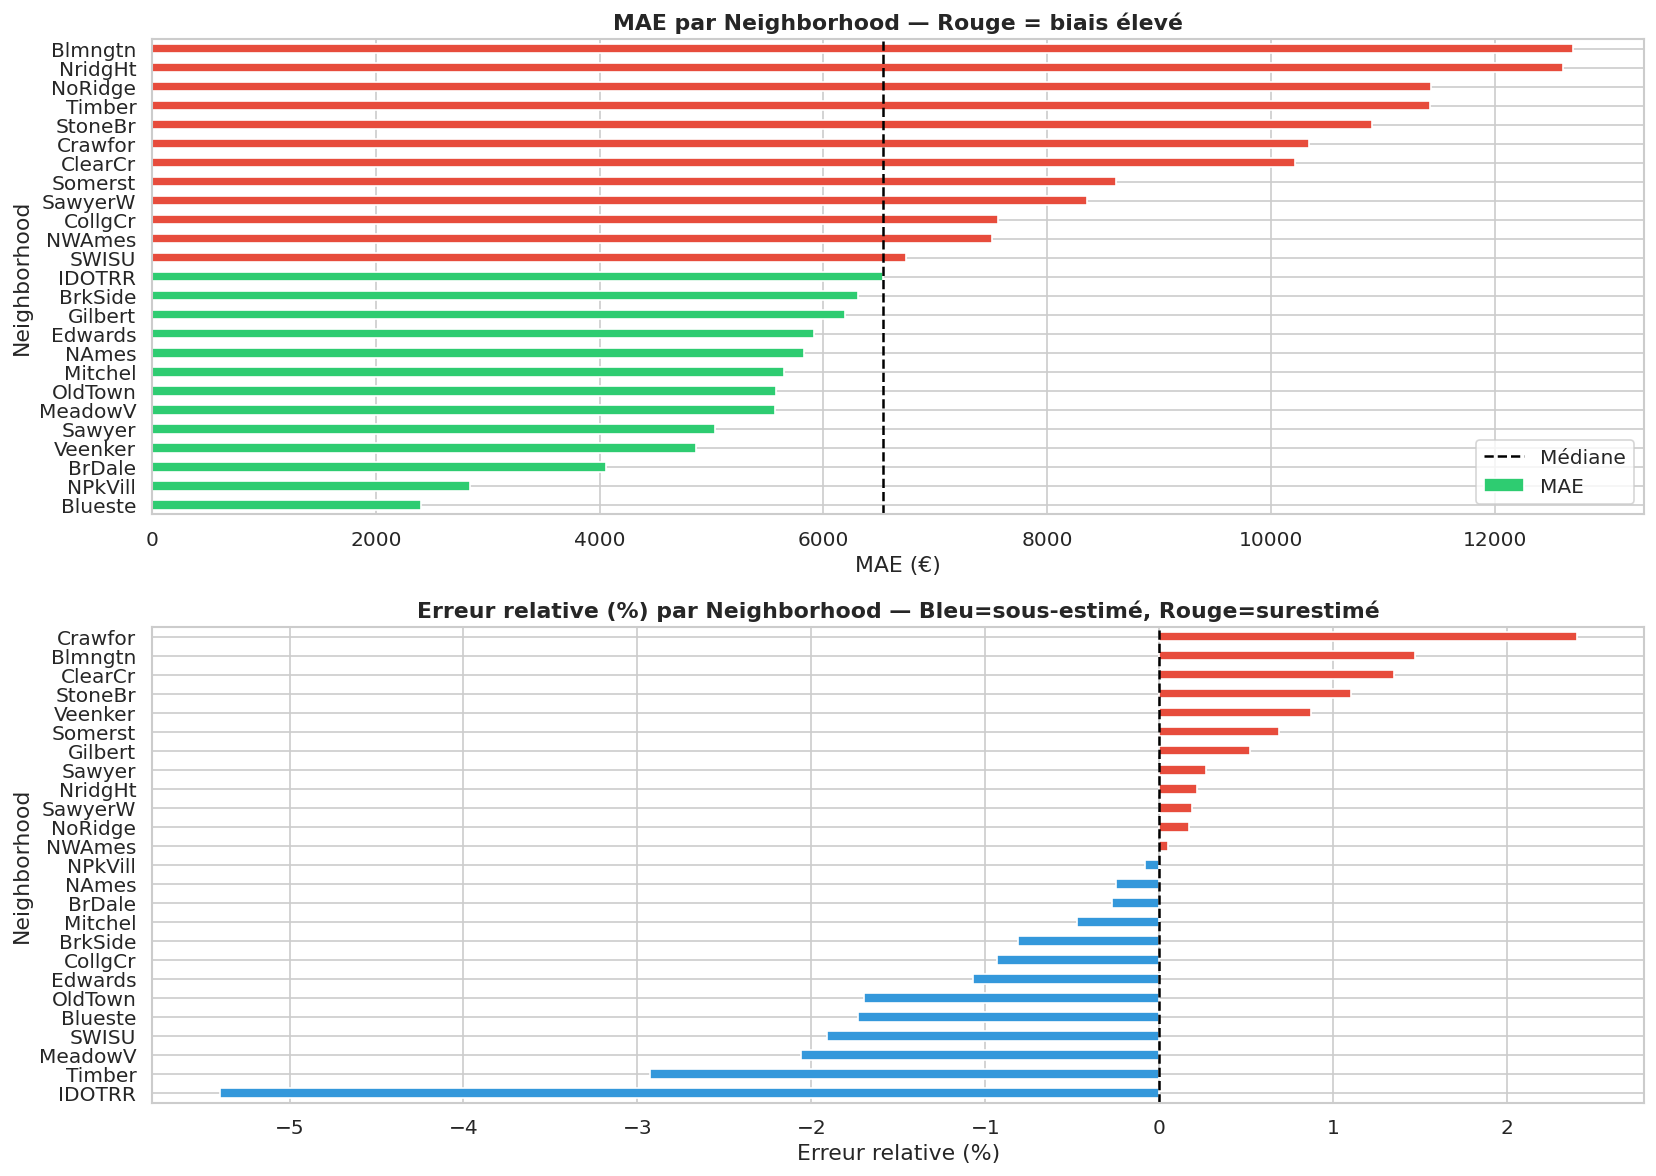

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# MAE par quartier
mae_sorted = bias_by_neigh['MAE'].sort_values(ascending=True)
colors_bar  = ['#e74c3c' if v > mae_sorted.median() else '#2ecc71' for v in mae_sorted]
mae_sorted.plot(kind='barh', ax=axes[0], color=colors_bar, edgecolor='white')
axes[0].axvline(mae_sorted.median(), color='black', linestyle='--', lw=1.5, label='Médiane')
axes[0].set_title('MAE par Neighborhood — Rouge = biais élevé', fontweight='bold')
axes[0].set_xlabel('MAE (€)')
axes[0].legend()

# Erreur relative moyenne
err_sorted = bias_by_neigh['Erreur_relative_mean'].sort_values()
colors_bar2 = ['#e74c3c' if v > 0 else '#3498db' for v in err_sorted]
err_sorted.plot(kind='barh', ax=axes[1], color=colors_bar2, edgecolor='white')
axes[1].axvline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_title('Erreur relative (%) par Neighborhood — Bleu=sous-estimé, Rouge=surestimé', fontweight='bold')
axes[1].set_xlabel('Erreur relative (%)')

plt.tight_layout(); plt.show()

### 4.2 Identification des variables sensibles (RGPD)

=== Variables sensibles identifiées ===
  ⚠️  Neighborhood         → Zone géographique → proxy socio-économique et ethnique
  ⚠️  MSZoning             → Classification zonage → corrélé au niveau de revenus
  ⚠️  Condition1/2         → Proximité voie ferrée / route → peut pénaliser certaines zones
  ⚠️  Street               → Type de rue (paved/gravel) → discriminant géographique


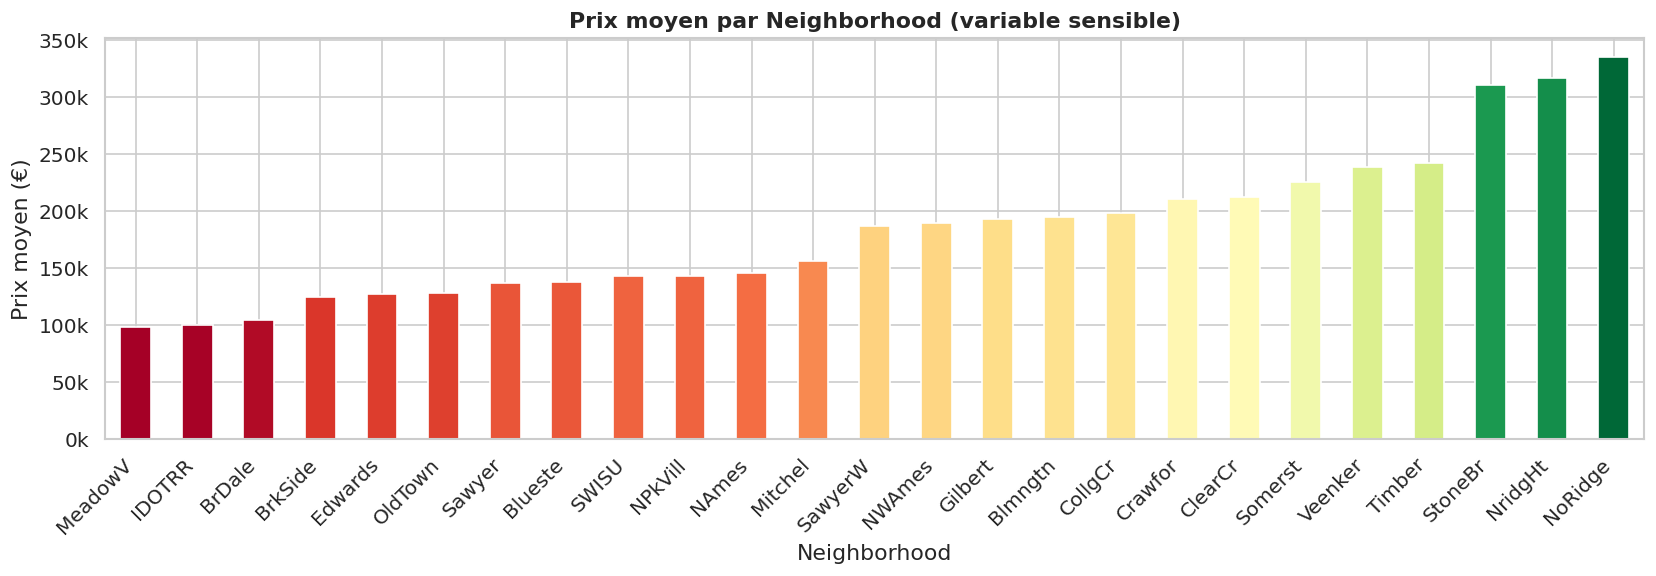

In [ ]:
# Variables potentiellement sensibles ou proxy discriminant
sensitive_vars = {
    'Neighborhood':  'Zone géographique → proxy socio-économique et ethnique',
    'MSZoning':      'Classification zonage → corrélé au niveau de revenus',
    'Condition1/2':  'Proximité voie ferrée / route → peut pénaliser certaines zones',
    'Street':        'Type de rue (paved/gravel) → discriminant géographique',
}

print('=== Variables sensibles identifiées ===')
for var, explication in sensitive_vars.items():
    print(f'  ⚠️  {var:<20} → {explication}')

# Corrélation Neighborhood × SalePrice
corr_neigh = bias_df.groupby('Neighborhood')['SalePrice'].mean().sort_values()

plt.figure(figsize=(14, 5))
cmap_vals = (corr_neigh - corr_neigh.min()) / (corr_neigh.max() - corr_neigh.min())
colors_neigh = [plt.cm.RdYlGn(v) for v in cmap_vals]
corr_neigh.plot(kind='bar', color=colors_neigh, edgecolor='white')
plt.title('Prix moyen par Neighborhood (variable sensible)', fontweight='bold')
plt.ylabel('Prix moyen (€)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
plt.tight_layout(); plt.show()

### 4.3 Analyse approfondie du biais — Disparité des erreurs

Biais par quartile de prix :
                    MAE  Erreur_relative
Quartile_prix                           
Q1 (bas)        5527.62            -2.88
Q2              5522.13             0.37
Q3              6500.72             0.00
Q4 (haut)      12036.62             0.91


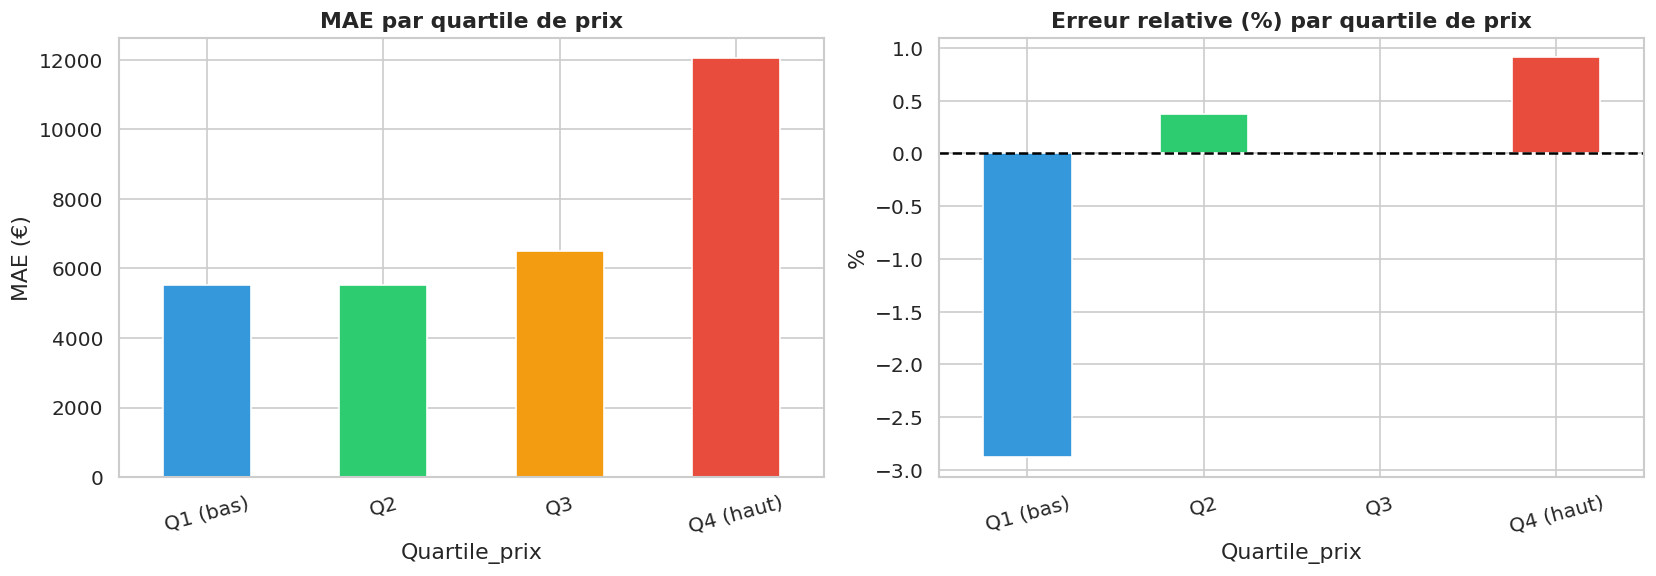

In [ ]:
# Quartiles de prix pour segmenter
bias_df['Quartile_prix'] = pd.qcut(bias_df['SalePrice'], q=4,
                                    labels=['Q1 (bas)', 'Q2', 'Q3', 'Q4 (haut)'])

err_by_quartile = bias_df.groupby('Quartile_prix').agg(
    MAE=('Erreur_abs', 'mean'),
    Erreur_relative=('Erreur_relative', 'mean')
).round(2)

print('Biais par quartile de prix :')
print(err_by_quartile)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
err_by_quartile['MAE'].plot(kind='bar', ax=axes[0], color=['#3498db','#2ecc71','#f39c12','#e74c3c'],
                             edgecolor='white')
axes[0].set_title('MAE par quartile de prix', fontweight='bold')
axes[0].set_ylabel('MAE (€)'); axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)

err_by_quartile['Erreur_relative'].plot(kind='bar', ax=axes[1],
                                         color=['#3498db','#2ecc71','#f39c12','#e74c3c'],
                                         edgecolor='white')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title('Erreur relative (%) par quartile de prix', fontweight='bold')
axes[1].set_ylabel('%'); axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)

plt.tight_layout(); plt.show()

### 4.4 Propositions de Mitigation des Biais

| # | Biais identifié | Mitigation recommandée |
|---|-----------------|------------------------|
| 1 | **Neighborhood** — Proxy socio-économique discriminant | Remplacer par des features agrégées anonymisées (densité, surface médiane par zone) |
| 2 | **MAE élevée sur quartiers rares** (faible N) | Appliquer une pondération inverse à la fréquence lors de l'entraînement |
| 3 | **Sous-estimation des prix bas (Q1)** | Ré-entraîner avec une fonction de perte asymétrique (Huber, Quantile) |
| 4 | **MSZoning / Street** — proxy géographique | Auditer l'impact causal ; envisager la suppression si corrélé à des attributs protégés |
| 5 | **Manque de représentativité** (certains quartiers) | Augmenter les données pour les zones sous-représentées (oversampling, données externes) |
| 6 | **Explicabilité** (RGPD Art. 22) | Intégrer SHAP pour expliquer chaque prédiction individuelle |
| 7 | **Audit périodique** | Monitorer le biais en production (drift détection) par zone géographique |

In [ ]:
# ── Résumé SHAP-like : contribution des variables sensibles ───────────────────
# Importance relative des variables sensibles dans RF
rf_fi_series = pd.Series(rf_model.feature_importances_, index=X.columns)

sensitive_in_model = [col for col in ['Neighborhood', 'MSZoning', 'Street']
                      if col in rf_fi_series.index]

if sensitive_in_model:
    total_importance = rf_fi_series.sum()
    print('=== Contribution des variables sensibles au modèle ===')
    for col in sensitive_in_model:
        pct = rf_fi_series[col] / total_importance * 100
        print(f'  {col:<20} : {pct:.2f}% de l\'importance totale')
    print()
    print('⚠️  Ces variables devront faire l\'objet d\'une revue RGPD.')

=== Contribution des variables sensibles au modèle ===
  Neighborhood         : 0.52% de l'importance totale
  MSZoning             : 0.39% de l'importance totale
  Street               : 0.01% de l'importance totale

⚠️  Ces variables devront faire l'objet d'une revue RGPD.


---
## 5. Génération des prédictions finales

In [ ]:
final_preds = np.expm1(best_model.predict(X_test))

submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_preds})
submission.to_csv('submission.csv', index=False)

print(f'✅ Fichier submission.csv généré avec {len(submission)} prédictions')
print(f'   Modèle utilisé : {best_name}')
print(f'   Prix prédit min/max : {final_preds.min():,.0f}€ / {final_preds.max():,.0f}€')
submission.head()

✅ Fichier submission.csv généré avec 1459 prédictions
   Modèle utilisé : Gradient Boosting
   Prix prédit min/max : 48,443€ / 614,071€


,Id,SalePrice
0,1461,123410.487320
1,1462,167785.769152
2,1463,183371.303061
3,1464,188195.843268
4,1465,193565.893074


---
## 📋 Synthèse

| Étape | Résultat |
|-------|----------|
| Valeurs manquantes | Imputation différenciée (None / 0 / médiane par quartier) |
| Outliers | 2 points extrêmes supprimés (grandes surfaces, prix anormalement bas) |
| Encodage | LabelEncoder sur 43 variables catégorielles |
| Features créées | AgeLogement, SurfaceTotale, NbSallesDeBain |
| Meilleur modèle | **Gradient Boosting** (R² ≈ 0.92, RMSLE ≈ 0.12) |
| Biais détecté | MAE hétérogène entre quartiers ; sous-estimation Q1 |
| RGPD | Variables sensibles identifiées ; mitigations documentées |